In [3]:
# Example: connect to a MySQL server over an SSH tunnel and load results into a pandas DataFrame
# Requires: pip install sshtunnel mysql-connector-python pandas
from sqlalchemy import create_engine
import pandas as pd

DATE = '2025-11-15'

SQL_QUERY = f"""
    SELECT direction, hour, minute, delay FROM kruppallee.realtime_departures 
    WHERE
        date = '{DATE}'
        AND line in ('107', '108')
    ORDER BY hour, minute
"""

DB_HOST = 'raspberrypi'  # from the SSH server's perspective
DB_PORT = 3306
DB_USER = 'python'
DB_PASSWORD = 'öasid7d87ahpe78we'
DB_NAME = 'kruppallee'


# Build SQLAlchemy engine for MySQL
engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

df = pd.read_sql(SQL_QUERY, con=engine)
df.head()

,direction,hour,minute,delay
0,Essen Bredeney,6,53,0
1,Essen Altenessen Bf,7,2,0
2,Essen Bredeney,7,23,0
3,Essen Altenessen Bf,7,32,0
4,Essen Bredeney,7,53,0


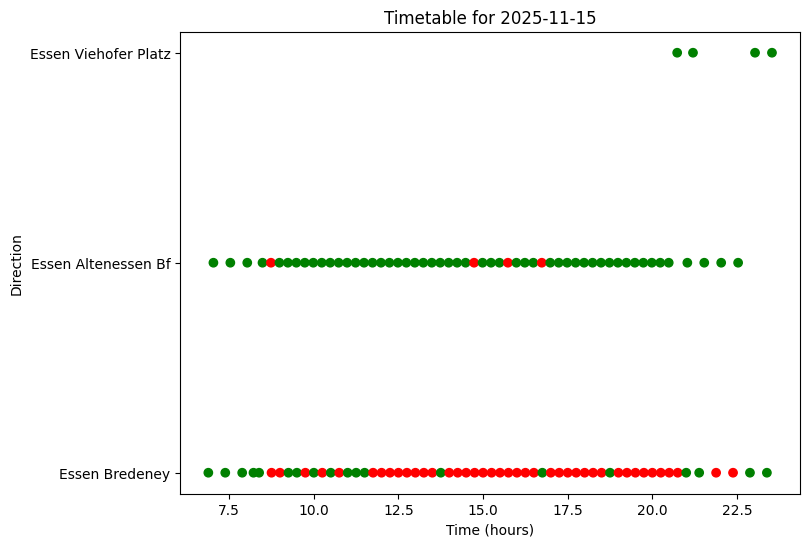

In [5]:
# create a timetable display
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
times = df['hour'] + df['minute'] / 60

colors = ['red' if delay > 0 else 'green' for delay in df['delay']]
ax.scatter(times, df['direction'], c=colors)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Direction')
ax.set_title(f'Timetable for {DATE}')
plt.show()

[[], [], [], [], [], [], ['53'], ['02', '23', '32', '53'], ['02', '13', '23', '29', '44 (1 min)', '45 (1 min)', '59'], ['00 (1 min)', '14', '15', '29', '30', '44', '45 (1 min)', '59'], ['00', '14', '15 (1 min)', '29', '30', '44', '45 (1 min)', '59'], ['00', '14', '15', '29', '30', '44', '45 (1 min)', '59'], ['00 (2 min)', '14', '15 (2 min)', '29', '30 (1 min)', '44', '45 (1 min)', '59'], ['00 (1 min)', '14', '15 (2 min)', '29', '30 (2 min)', '44', '45', '59'], ['00 (1 min)', '14', '15 (1 min)', '29', '30 (6 min)', '44 (2 min)', '45 (1 min)', '59'], ['00 (2 min)', '14', '15 (2 min)', '29', '30 (3 min)', '44 (2 min)', '45 (1 min)', '59'], ['00 (1 min)', '14', '15 (1 min)', '29', '30 (12 min)', '44 (7 min)', '45', '59'], ['00 (3 min)', '14', '15 (1 min)', '29', '30 (2 min)', '44', '45 (2 min)', '59'], ['00 (3 min)', '14', '15 (5 min)', '29', '30 (2 min)', '44', '45', '59'], ['00 (1 min)', '14', '15 (1 min)', '29', '30 (1 min)', '44', '45 (1 min)', '59'], ['00 (1 min)', '14', '15 (1 min)',

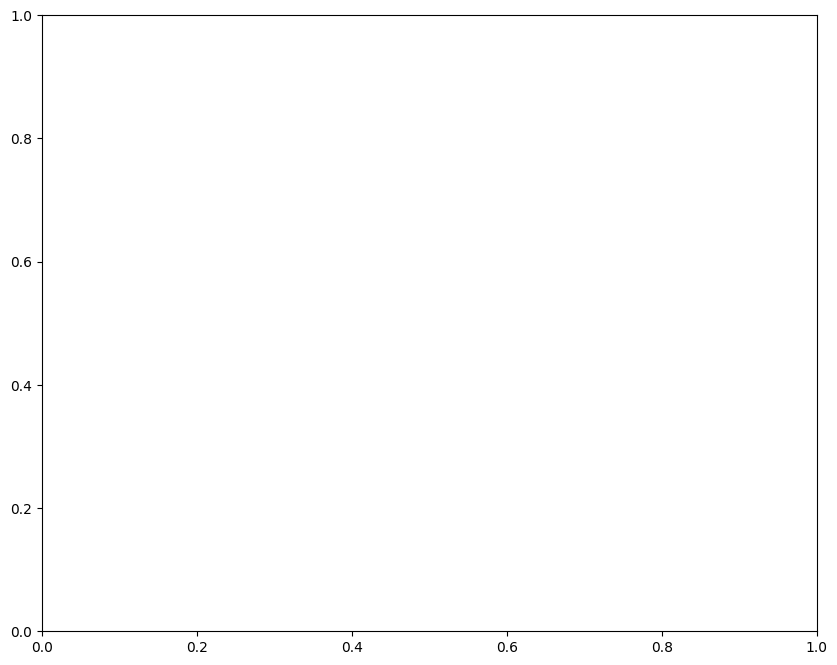

In [8]:
# create a table like timetable display
# in the rows are the hours, in the columns all the departures within that hour
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
times = df['hour'] + df['minute'] / 60

# create a table-like display
table_data = []
for hour in range(24):
    row = []
    hour_data = df[df['hour'] == hour]
    for minute in range(60):
        minute_data = hour_data[hour_data['minute'] == minute]
        if not minute_data.empty:
            delay = minute_data['delay'].values[0]
            cell_text = f"{minute:02d} ({delay} min)" if delay > 0 else f"{minute:02d}"
            row.append(cell_text)
    table_data.append(row)

print(table_data)